# Initial conditions for PBH Hawking radiation

Determine redshifts for Hongmeng, EDGES has zmax ~ 30

In [ ]:
import PyLab as PL
from PyLab import np, plt
freq_HM_MHz = np.array([30, 120])
HM_zmax = np.max(1420/freq_HM_MHz-1)
print("zmax for Hongmeng: {:.2f}".format(np.max(HM_zmax)))
# Ok Hongmeng has zmax 46.33, let's use 48
m_range = [1.3E14, 3E14]
zmax = 48

zmax for Hongmeng: 46.33


In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
%matplotlib widget

48.5183398189544 0.00024329975873457277


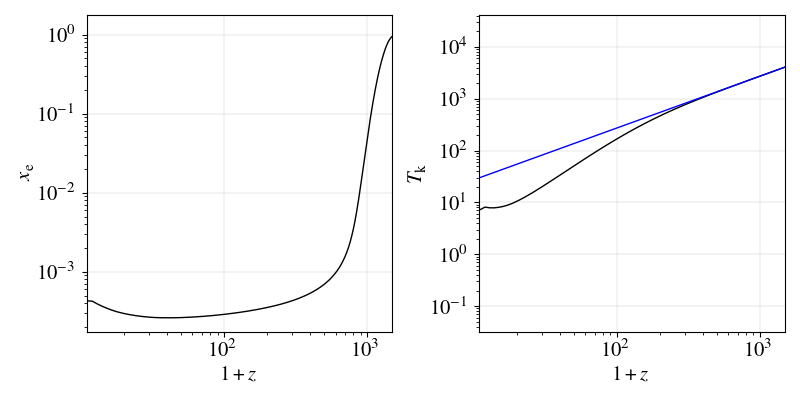

In [22]:
def Find_ICS(mbh = 3E14, fbh = 1E-10, Use_Tk_max = 0, make_plot = 0):
    d = PL.HyRec(mbh=mbh, fbh=fbh, Use_Tk_max=Use_Tk_max)
    z_ax = d['z'][::-1]
    Xe_ax = d['xe'][::-1]
    T_ax = d['Tk'][::-1]
    T_ICS = np.interp(x = zmax, xp = z_ax, fp = T_ax, left = np.nan, right = np.nan)
    Xe_ICS = np.interp(x = zmax, xp = z_ax, fp = Xe_ax, left = np.nan, right = np.nan)
    fHe = 0.08112582781456953 # nHe/nH for Yhe = 0.245
    Xe_ICS = Xe_ICS / (1+fHe) # Convert to 21cmFAST format, good before Helium full ionization
    if Xe_ICS > 0.99: Xe_ICS = 0.99 # Set a ceiling
    
    # Make plot
    if make_plot:
        LineWidth = 1
        FontSize = 15
        plt.rcParams.update({
            'text.usetex': True,
            'font.family':'Times',
            'text.latex.preamble': r'\usepackage{newtxtext,newtxmath}'})
        fig, axs = plt.subplots(1, 2, sharex = False, sharey = False)
        fig.set_size_inches(8, 4)
        axs[0].grid(True, which='major', linewidth = 0.2) # Show grid, if u wanna show both minor and major grid, use which='both'
        axs[0].loglog(1+z_ax, Xe_ax, 'k', linewidth = LineWidth)
        axs[0].set_xlabel('$1+z$',fontsize=FontSize,fontname='Times New Roman')
        axs[0].set_ylabel('$x_{\mathrm{e}}$',fontsize=FontSize,fontname='Times New Roman')
        axs[0].tick_params(axis='both', which='both', labelsize = FontSize)
        axs[0].set_xlim(11, 1500)
        # axs[0].set_ylim(-1.2, 1.2)

        axs[1].grid(True, which='major', linewidth = 0.2) # Show grid, if u wanna show both minor and major grid, use which='both'
        axs[1].loglog(1+z_ax, T_ax, 'k', linewidth = LineWidth)
        axs[1].loglog(1+z_ax, 2.728*(1+z_ax), 'b', linewidth = LineWidth)
        axs[1].set_xlabel('$1+z$',fontsize=FontSize,fontname='Times New Roman')
        axs[1].set_ylabel('$T_{\mathrm{k}}$',fontsize=FontSize,fontname='Times New Roman')
        axs[1].tick_params(axis='both', which='both', labelsize = FontSize)
        axs[1].set_xlim(11, 1500)
        # axs[0].set_ylim(-1.2, 1.2)
        plt.xticks(size=FontSize)
        plt.yticks(size=FontSize)
        plt.tight_layout()
    return T_ICS, Xe_ICS

t, x = Find_ICS(make_plot=1)
print(t, x)
